In [8]:
import torch

print("="*50)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)
    print("GPU Count :", torch.cuda.device_count())
print("="*50)

CUDA Available : True
GPU : Tesla T4
CUDA Version : 12.8
GPU Count : 1


In [9]:
!nvidia-smi

Tue Jun 30 10:22:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
import sys

print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [17]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ope

In [1]:
import onnxruntime as ort

print("Available Providers:")
print(ort.get_available_providers())

Available Providers:
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']


In [ ]:
import os

MODEL_PATH = "/content/rfdetr-seg-small.onnx"

print(os.path.exists(MODEL_PATH))

In [2]:
import torch

x = torch.rand(5, device="cuda")

print(x)
print(x.device)

tensor([0.2569, 0.6093, 0.4192, 0.2816, 0.4925], device='cuda:0')
cuda:0


In [3]:
import onnxruntime as ort

session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CUDAExecutionProvider"]
)

print(session.get_providers())

['CPUExecutionProvider']


In [4]:
for i in session.get_inputs():
    print(i.name, i.shape)

print()

for o in session.get_outputs():
    print(o.name, o.shape)

input [1, 3, 384, 384]

dets [1, 100, 4]
labels [1, 100, 11]
masks [1, 100, 96, 96]


In [5]:
import onnxruntime as ort

print("Available Providers:")
print(ort.get_available_providers())

print("\nDefault Device:")
print(ort.get_device())

Available Providers:
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']

Default Device:
GPU


In [7]:
import onnxruntime as ort

session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",     
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

print(session.get_providers())

['CPUExecutionProvider']


In [8]:
import onnxruntime as ort

print(ort.__version__)

1.17.1


In [11]:
print(ort.get_available_providers())
print(ort.get_device())
print(ort.__version__)

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
GPU
1.17.1


In [12]:
import onnxruntime as ort

so = ort.SessionOptions()
so.log_severity_level = 0   

session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    sess_options=so,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

print(session.get_providers())

['CPUExecutionProvider']


In [19]:
!pip uninstall -y onnxruntime onnxruntime-gpu

Found existing installation: onnxruntime-gpu 1.17.1
Uninstalling onnxruntime-gpu-1.17.1:
  Successfully uninstalled onnxruntime-gpu-1.17.1


In [20]:
!pip install -U onnxruntime-gpu

  Using cached onnxruntime_gpu-1.27.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.7 kB)
Using cached onnxruntime_gpu-1.27.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (220.3 MB)


In [1]:
!pip install onnxruntime-gpu==1.22.0

  Using cached onnxruntime_gpu-1.22.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 1.7 MB/s eta 0:00:00
  Attempting uninstall: onnxruntime-gpu
    Found existing installation: onnxruntime-gpu 1.27.0
    Uninstalling onnxruntime-gpu-1.27.0:
      Successfully uninstalled onnxruntime-gpu-1.27.0


In [3]:
session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CUDAExecutionProvider","CPUExecutionProvider"]
)

print(session.get_providers())

['CUDAExecutionProvider', 'CPUExecutionProvider']


In [9]:
import cv2
import numpy as np
import onnxruntime as ort
import time

In [7]:
IMAGE_PATH = "/content/18Q1_bmp.rf.VGyJXlbIvvm29TkjhHdT.bmp"

image = cv2.imread(IMAGE_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [10]:
INPUT_SIZE = (384, 384)

img = cv2.resize(image, INPUT_SIZE)

img = img.astype(np.float32) / 255.0

img = np.transpose(img, (2, 0, 1))

img = np.expand_dims(img, axis=0)

img = np.ascontiguousarray(img)

In [11]:
cpu_session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CPUExecutionProvider"]
)

In [12]:
gpu_session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CUDAExecutionProvider"]
)

In [13]:
for _ in range(10):
    cpu_session.run(None, {"input": img})

for _ in range(10):
    gpu_session.run(None, {"input": img})

In [14]:
def benchmark(session, input_tensor, runs=100):

    times = []

    for _ in range(runs):

        start = time.perf_counter()

        outputs = session.run(
            None,
            {"input": input_tensor}
        )

        end = time.perf_counter()

        times.append(end - start)

    avg_time = np.mean(times)

    fps = 1 / avg_time

    latency = avg_time * 1000

    return avg_time, latency, fps

In [15]:
cpu_time, cpu_latency, cpu_fps = benchmark(cpu_session, img)

print("="*40)
print("CPU")
print("="*40)
print(f"Average Time : {cpu_time:.4f} sec")
print(f"Latency      : {cpu_latency:.2f} ms")
print(f"FPS          : {cpu_fps:.2f}")

CPU
Average Time : 0.9380 sec
Latency      : 937.98 ms
FPS          : 1.07


In [16]:
gpu_time, gpu_latency, gpu_fps = benchmark(gpu_session, img)

print("="*40)
print("GPU")
print("="*40)
print(f"Average Time : {gpu_time:.4f} sec")
print(f"Latency      : {gpu_latency:.2f} ms")
print(f"FPS          : {gpu_fps:.2f}")

GPU
Average Time : 0.0313 sec
Latency      : 31.32 ms
FPS          : 31.93


In [17]:
speedup = cpu_time / gpu_time

print("="*40)
print("Comparison")
print("="*40)

print(f"CPU Latency : {cpu_latency:.2f} ms")
print(f"GPU Latency : {gpu_latency:.2f} ms")

print(f"CPU FPS     : {cpu_fps:.2f}")
print(f"GPU FPS     : {gpu_fps:.2f}")

print(f"Speedup     : {speedup:.2f}x")

Comparison
CPU Latency : 937.98 ms
GPU Latency : 31.32 ms
CPU FPS     : 1.07
GPU FPS     : 31.93
Speedup     : 29.95x


In [22]:
import torch
import cv2

image = cv2.imread("/content/18Q1_bmp.rf.VGyJXlbIvvm29TkjhHdT.bmp")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tensor = torch.from_numpy(image).cuda().float()
tensor = tensor.permute(2, 0, 1).unsqueeze(0)
tensor = tensor / 255.0

tensor = torch.nn.functional.interpolate(
    tensor,
    size=(384, 384),
    mode="bilinear",
    align_corners=False
)

In [23]:
import time
import cv2
import numpy as np

IMAGE_PATH = "/content/18Q1_bmp.rf.VGyJXlbIvvm29TkjhHdT.bmp"

times = []

for _ in range(100):

    start = time.perf_counter()

    image = cv2.imread(IMAGE_PATH)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (384,384))

    image = image.astype(np.float32)/255.0

    image = np.transpose(image,(2,0,1))

    image = np.expand_dims(image,0)

    end = time.perf_counter()

    times.append(end-start)

print(f"CPU Preprocessing : {np.mean(times)*1000:.2f} ms")

CPU Preprocessing : 2.06 ms


In [24]:
import torch
import torch.nn.functional as F
import time
import cv2
import numpy as np

times = []

for _ in range(100):

    start = time.perf_counter()

    image = cv2.imread(IMAGE_PATH)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tensor = torch.from_numpy(image).cuda().float()

    tensor = tensor.permute(2,0,1).unsqueeze(0)

    tensor = tensor/255.0

    tensor = F.interpolate(
        tensor,
        size=(384,384),
        mode="bilinear",
        align_corners=False
    )

    torch.cuda.synchronize()

    end = time.perf_counter()

    times.append(end-start)

print(f"GPU Preprocessing : {np.mean(times)*1000:.2f} ms")

GPU Preprocessing : 1.96 ms


In [28]:
import onnxruntime as ort

gpu_session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CUDAExecutionProvider"]
)

In [32]:
def gpu_pipeline(image_path, session):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tensor = torch.from_numpy(image).cuda().float()
    tensor = tensor.permute(2, 0, 1).unsqueeze(0)
    tensor = tensor / 255.0

    tensor = F.interpolate(
        tensor,
        size=(384, 384),
        mode="bilinear",
        align_corners=False
    )

   
    input_np = tensor.cpu().numpy()

    outputs = session.run(
        None,
        {"input": input_np}
    )

    return outputs

In [33]:
times = []

for _ in range(100):

    start = time.perf_counter()

    gpu_pipeline("/content/18Q1_bmp.rf.VGyJXlbIvvm29TkjhHdT.bmp",gpu_session)

    end = time.perf_counter()

    times.append(end-start)

avg = np.mean(times)

print("="*40)
print("GPU COMPLETE PIPELINE")
print("="*40)

print(f"Latency : {avg*1000:.2f} ms")
print(f"FPS      : {1/avg:.2f}")

GPU COMPLETE PIPELINE
Latency : 32.87 ms
FPS      : 30.42


In [35]:
CLASS_NAMES = {
    0: "Valeo-MX",
    1: "solder",
    2: "solder-chip",
    3: "solder-large",
    4: "solder-long",
    5: "solder-middle",
    6: "solder-pin",
    7: "solder-square",
    8: "throughhole",
    9: "voids"
}

In [39]:
import numpy as np

class PostProcessor:

    def softmax(self, logits):
        logits = logits - np.max(logits)
        exp = np.exp(logits)
        return exp / np.sum(exp)

    def process(self, outputs):

        logits = np.array(outputs).squeeze()

        probs = self.softmax(logits)

        idx = int(np.argmax(probs))
        conf = float(probs[idx])

        return {
            "class_id": idx,
            "confidence": conf,
            "probabilities": probs
        }

In [49]:
import onnxruntime as ort

class ONNXInference:

    def __init__(self, model_path):

        self.session = ort.InferenceSession(
            model_path,
            providers=["CUDAExecutionProvider"]  
        )

        self.input_name = self.session.get_inputs()[0].name
        self.output_names = [o.name for o in self.session.get_outputs()]

        print("Loaded GPU ONNX Model")

    def infer(self, input_tensor):

        outputs = self.session.run(
            self.output_names,
            {self.input_name: input_tensor}
        )

        return {
            "dets": outputs[0],
            "labels": outputs[1],
            "masks": outputs[2]
        }

In [61]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import onnxruntime as ort



session = ort.InferenceSession(
    "/content/rfdetr-seg-small.onnx",
    providers=["CUDAExecutionProvider"]
)



CLASS_NAMES = {
    0: "Valeo-MX",
    1: "solder",
    2: "solder-chip",
    3: "solder-large",
    4: "solder-long",
    5: "solder-middle",
    6: "solder-pin",
    7: "solder-square",
    8: "throughhole",
    9: "voids"
}


def run_instance_all(image_path, conf_thres=0.3):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    
    tensor = torch.from_numpy(image).float().cuda()
    tensor = tensor.permute(2, 0, 1).unsqueeze(0) / 255.0

    tensor = F.interpolate(
        tensor,
        size=(384, 384),
        mode="bilinear",
        align_corners=False
    )

    input_np = tensor.cpu().numpy()

    
    dets, labels, masks = session.run(None, {"input": input_np})

    dets = dets[0]       # [100, 4]
    labels = labels[0]   # [100, 11]
    masks = masks[0]     # [100, 96, 96]

    result_img = image.copy()

   
    for i in range(len(dets)):

        class_probs = labels[i]
        score = np.max(class_probs)

        if score < conf_thres:
            continue

        class_id = np.argmax(class_probs)

        x1, y1, x2, y2 = dets[i].astype(int)

     
        mask = masks[i]
        mask = (mask > 0.5).astype(np.uint8)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

       
        color = np.zeros_like(image)
        color[:, :, 0] = mask * 255

        result_img = cv2.addWeighted(result_img, 1.0, color, 0.4, 0)

        
        cv2.rectangle(result_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = f"{CLASS_NAMES.get(class_id, class_id)} {score:.2f}"

        cv2.putText(
            result_img,
            label,
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            2
        )
        cv2.putText(
          output,
    "GPU ONNX INFERENCE",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

   
    plt.figure(figsize=(8, 8))
    plt.imshow(result_img)
    plt.axis("off")
    plt.show()

    return result_img

In [51]:
import cv2
import numpy as np

class Preprocessor:

    def __init__(self, input_size=(640, 640)):
        self.w, self.h = input_size

    def preprocess(self, image_path):

        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(image_path)

        original = image.copy()
        original_h, original_w = image.shape[:2]

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.w, self.h))

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        image = np.expand_dims(image, axis=0)

        return {
            "input_tensor": image.astype(np.float32),
            "original_image": original,
            "original_size": (original_h, original_w)
        }

In [56]:
import cv2
import numpy as np
import json

class PostProcessor:

    def __init__(self,
                 class_map_path="/content/num_to_class.json",
                 conf_threshold=0.5,
                 mask_threshold=0.5,
                 background_class=10):

        with open(class_map_path, "r") as f:
            class_to_idx = json.load(f)

        self.idx_to_class = {v: k for k, v in class_to_idx.items()}

        self.CONF_THRESHOLD = conf_threshold
        self.MASK_THRESHOLD = mask_threshold
        self.BACKGROUND_CLASS = background_class

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    def convert_box(self, box, img_w, img_h):

        cx, cy, w, h = box

        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h

        return [int(x1), int(y1), int(x2), int(y2)]

    def process(self, outputs, original_size):

        img_h, img_w = original_size

        dets = outputs["dets"][0]
        labels = outputs["labels"][0]
        masks = outputs["masks"][0]

        final_boxes, final_scores, final_labels, final_masks = [], [], [], []

        for i in range(len(dets)):

            probs = self.sigmoid(labels[i])

            class_id = int(np.argmax(probs))
            conf = float(probs[class_id])

            if conf < self.CONF_THRESHOLD:
                continue

            if class_id == self.BACKGROUND_CLASS:
                continue

            box = self.convert_box(dets[i], img_w, img_h)

            mask = self.sigmoid(masks[i])
            mask = (mask > self.MASK_THRESHOLD).astype(np.uint8)

            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

            final_boxes.append(box)
            final_scores.append(conf)
            final_labels.append(class_id)
            final_masks.append(mask)

        return {
            "boxes": np.array(final_boxes),
            "scores": np.array(final_scores),
            "labels": np.array(final_labels),
            "masks": final_masks
        }

In [53]:
import cv2
import numpy as np

CLASS_NAMES = {
    0: "Valeo-MX",
    1: "solder",
    2: "solder-chip",
    3: "solder-large",
    4: "solder-long",
    5: "solder-middle",
    6: "solder-pin",
    7: "solder-square",
    8: "throughhole",
    9: "voids"
}

class Visualizer:

    def __init__(self):
        self.colors = [
            (0,255,0),(255,0,0),(0,0,255),
            (255,255,0),(255,0,255),
            (0,255,255),(150,100,255),
            (255,150,100),(100,255,150),
            (180,180,0)
        ]

    def draw(self, image, result):

        output = image.copy()
        h, w = image.shape[:2]

        for i in range(len(result["boxes"])):

            x1, y1, x2, y2 = result["boxes"][i]
            class_id = int(result["labels"][i])
            score = float(result["scores"][i])

            color = self.colors[class_id % len(self.colors)]

            # MASK
            mask = result["masks"][i]
            mask = cv2.resize(mask.astype(np.float32), (w, h))
            mask = (mask > 0).astype(np.uint8)

            colored = np.zeros_like(output)
            colored[:, :, 0] = mask * color[0]
            colored[:, :, 1] = mask * color[1]
            colored[:, :, 2] = mask * color[2]

            output = cv2.addWeighted(output, 1.0, colored, 0.35, 0)

            # BOX
            cv2.rectangle(output, (x1,y1), (x2,y2), color, 2)

            text = f"{CLASS_NAMES[class_id]} {score:.2f}"

            cv2.putText(output, text, (x1, max(20,y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        return output

In [54]:
def run(image_path):

    pre = Preprocessor()
    model = ONNXInference("/content/rfdetr-seg-small.onnx")
    post = PostProcessor()
    vis = Visualizer()

    data = pre.preprocess(image_path)

    outputs = model.infer(data["input_tensor"])

    result = post.process(outputs, data["original_size"])

    img = vis.draw(data["original_image"], result)

    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Loaded GPU ONNX Model


/tmp/ipykernel_7195/3814473364.py:24: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


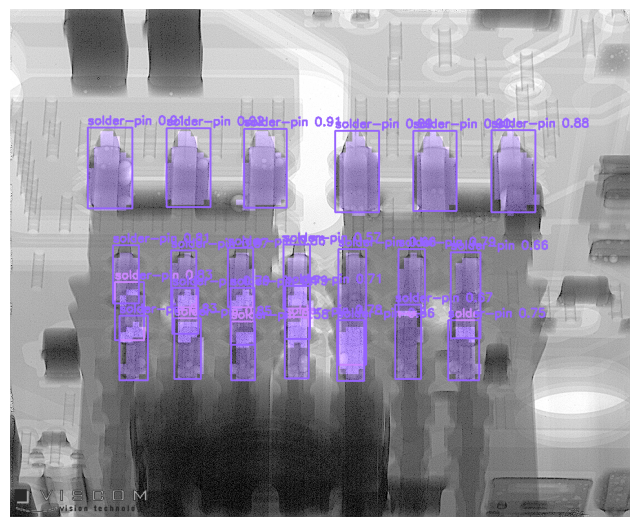

In [67]:


image_path = "/content/23W_bmp.rf.bqnZGQMjvx3aWRRjtq0V.bmp"
model_path = "/content/rfdetr-seg-small.onnx"


pre = Preprocessor(input_size=(384, 384))
model = ONNXInference(model_path)
post = PostProcessor()
vis = Visualizer()


data = pre.preprocess(image_path)


outputs = model.infer(data["input_tensor"])


result = post.process(outputs, data["original_size"])


final_image = vis.draw(data["original_image"], result)


import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(final_image)
plt.axis("off")
plt.show()